Download and Import libraries

In [2]:
%pip install scikit-learn seaborn matplotlib scipy --default-timeout=1000 --no-cache-dir

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 311.4 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 5.5 MB/s eta 0:00:00ta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.1/130.1 kB 639.7 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 1.7 MB/s eta 0:00:0000:0100:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 4.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 3.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 3.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.2/383.2 kB 4.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 3.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 5.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 4.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
import pandas as pd 
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as st
from sklearn import ensemble, tree ,linear_model



Load the data

In [4]:
# fetch dataset 
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296) 


/home/sensei/patient-readmission-predictor/patient-readmission-predictor-lab/lib/python3.12/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [5]:
df=diabetes_130_us_hospitals_for_years_1999_2008

# # data (as pandas dataframes) 
X = df.data.features 
y = df.data.targets 
  
# metadata 
print("Dataset metadata")
print(df.metadata,"\n\n\n") 
  
# variable information 
print("Dataset variables")
print(df.variables,"\n\n\n") 

# header information
print("List of headers")
print(df.data.headers,"\n\n\n")


# original features
print("Original features")
print(df.data.original,"\n\n\n")

# targets
print("Targets")
print(df.data.targets,"\n\n\n")


# features
print("Features")
print(df.data.features,"\n\n\n")


Dataset metadata
{'uci_id': 296, 'name': 'Diabetes 130-US Hospitals for Years 1999-2008', 'repository_url': 'https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008', 'data_url': 'https://archive.ics.uci.edu/static/public/296/data.csv', 'abstract': 'The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failu

In [6]:
# VARIABLES EXPLORATION
print("A-EXPLORING VARIABLES")
print("***** FIRST 5 ROWS")
print(df.variables.head(),"\n\n\n")

# print("***** CONCISE SUMMARY OF DATASET")
print(df.variables.info(),"\n\n\n")

# print("***** DIMENSIONS-NUMBER OF ROWS AND COLUMNS")
print(df.variables.shape,"\n\n\n")

# print("***** QUICK STATISTICAL SUMMARY")
print(df.variables.describe(include="all"),"\n\n\n")

# print("***** NUMBER OF MISSING OR NULL VALUES")
print(df.variables.isnull().sum(),"\n\n\n")

# print("***** NUMBER OF REPETITIVE VALUES")
print(df.variables.duplicated().sum(),"\n\n\n")






# DATA EXPLORATION
print("\n\n\n\n B-EXPLORING DATA")
print("***** Shape of the data block")
print(df.data.shape)






# METADATA EXPLORATION
print("\n\n\n\n C-EXPLORING METADATA")
print("***** DIMENSIONS-NUMBER OF ROWS AND COLUMNS")
print(df.metadata.shape,"\n\n\n")






A-EXPLORING VARIABLES
***** FIRST 5 ROWS
           name     role         type demographic  \
0  encounter_id       ID                      NaN   
1   patient_nbr       ID                      NaN   
2          race  Feature  Categorical        Race   
3        gender  Feature  Categorical      Gender   
4           age  Feature  Categorical         Age   

                                         description units missing_values  
0                  Unique identifier of an encounter  None             no  
1                     Unique identifier of a patient  None             no  
2  Values: Caucasian, Asian, African American, Hi...  None            yes  
3          Values: male, female, and unknown/invalid  None             no  
4  Grouped in 10-year intervals: [0, 10), [10, 20...  None             no   



<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 

HANLDE MISSING VALUES

Count missing values
name               0
role               0
type               0
demographic       47
description        0
units             50
missing_values     0
dtype: int64 



Show percentage of missing values
name                0.0
role                0.0
type                0.0
demographic        94.0
description         0.0
units             100.0
missing_values      0.0
dtype: float64 





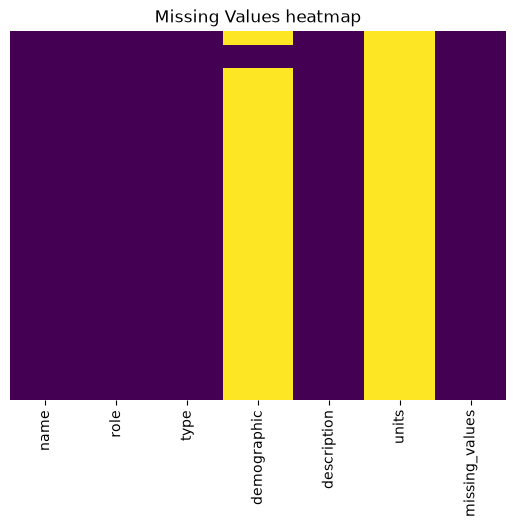

In [7]:
print("Count missing values")
print(df.variables.isnull().sum(),"\n\n\n")

print("Show percentage of missing values")
print((df.variables.isnull().mean()*100).round(2),"\n\n\n")

# Visual overview
sns.heatmap(df.variables.isnull(),cbar=False,yticklabels=False,cmap="viridis")
plt.title("Missing Values heatmap")
plt.show()

In [ ]:
Univariate non-graphical Analysis

In [60]:
print("GROUPINGS IN VARIABLES")
print(df.variables.keys(),"\n\n\n")

print("GROUPINGS IN DATA")
print(df.data.keys(),"\n\n\n")


print("DATA TYPES OF VALUES IN VARIABLES")
for key in df.variables.keys():
    print(key,"is of data type",type(key))
print("\n\n\n")

print("DATA TYPES OF VALUES IN DATA")
for key in df.data.keys():
    print(key,"is of data type",type(key))
print("\n\n\n")


print("MEAN OF VARIABLES")

print("MEDIAN OF VARIABLES")
# print(df.variables.median,"\n\n\n")

print("MODE OF VARIABLES")
# print(df.variables.mode,"\n\n\n")


GROUPINGS IN VARIABLES
Index(['name', 'role', 'type', 'demographic', 'description', 'units',
       'missing_values'],
      dtype='str') 



GROUPINGS IN DATA
dict_keys(['ids', 'features', 'targets', 'original', 'headers']) 



DATA TYPES OF VALUES IN VARIABLES
name is of data type <class 'str'>
role is of data type <class 'str'>
type is of data type <class 'str'>
demographic is of data type <class 'str'>
description is of data type <class 'str'>
units is of data type <class 'str'>
missing_values is of data type <class 'str'>




DATA TYPES OF VALUES IN DATA
ids is of data type <class 'str'>
features is of data type <class 'str'>
targets is of data type <class 'str'>
original is of data type <class 'str'>
headers is of data type <class 'str'>




MEAN OF VARIABLES
MEDIAN OF VARIABLES
MODE OF VARIABLES
